In [1]:
# 导入必要的包
import pandas as pd  # 数据处理

# 分类类型（用于其他章节的 Malmquist 指数分解，本章碳排放效率案例不使用，保留以保持与配套 notebook 一致）
from pandas.api.types import CategoricalDtype
cat_size_order = CategoricalDtype(
    ['MQ', 'MEFFCH', 'MTECHCH'],  # MQ: Malmquist指数; MEFFCH: 效率变化; MTECHCH: 技术进步
    ordered=True
)

# 设置分析类型
kind = "province"  # 当前设置为省份级分析

# 根据分析类型加载不同的数据集
if kind == "province":
    dmuname = '省份'  # 设置决策单元名称为"省份"
    # 读取中国省份数据
    data = (pd.read_excel(r"../../data/china data.xlsx")
            .query('year>2015')
            .reset_index(drop=True))

    region = data[["省份","group"]]  # 提取省份和区域分组信息
else:
    dmuname = '国家'  # 设置决策单元名称为"国家"
    # 读取OECD国家数据
    data = (pd.read_excel(r"../../data/oecd data.xlsx")
            .query('year>2015')
            .reset_index(drop=True))

# 提取年份和决策单元信息
yearid = data[['year', dmuname]]  # 选择年份和DMU名称列
yearid[dmuname].unique()  # 显示所有唯一的决策单元名称
# 全局中文字体设置（所有绘图 cell 共享）
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['STSong']  # 设置中文字体为华文宋体
rcParams['axes.unicode_minus'] = False
%matplotlib inline


In [2]:
data

,省份,year,Y,E,L,K,CO2,group
0,上海市,2016,902.794998,11286.777262,1365.24,4.085533e+06,188.140000,E
1,上海市,2017,929.498785,11423.298889,1372.65,4.238459e+06,190.480000,E
2,上海市,2018,951.911601,11072.057032,1375.66,5.790083e+06,190.641610,E
3,上海市,2019,947.300532,11536.380416,1376.20,6.373635e+06,192.912182,E
4,云南省,2016,427.550554,9360.041199,2855.00,4.787612e+06,180.050000,W
...,...,...,...,...,...,...,...,...
115,青海省,2019,62.322152,3566.776509,330.20,1.164860e+06,51.752403,W
116,黑龙江省,2016,394.193978,9307.525536,1776.00,4.500560e+06,269.340000,C
117,黑龙江省,2017,384.949317,9192.427176,1699.00,4.867986e+06,268.660000,C
118,黑龙江省,2018,384.333468,7514.188572,1635.00,4.611428e+06,248.035933,C


In [3]:
yearid[dmuname].unique()  # 显示所有唯一的决策单元名称

array(['上海市', '云南省', '内蒙古自治区', '北京市', '吉林省', '四川省', '天津市', '宁夏回族自治区',
       '安徽省', '山东省', '山西省', '广东省', '广西壮族自治区', '新疆维吾尔自治区', '江苏省', '江西省',
       '河北省', '河南省', '浙江省', '海南省', '湖北省', '湖南省', '甘肃省', '福建省', '贵州省',
       '辽宁省', '重庆市', '陕西省', '青海省', '黑龙江省'], dtype=object)

## 10.6.1 CNLSDDFb

In [4]:
# 导入必要的模块
from deabook import CNLSSDFDDFweak, StoNED  # 导入CNLS含非期望产出距离函数模块与StoNED类
from deabook.constant import FUN_PROD, OPT_LOCAL, RTS_VRS1, RTS_VRS2, RED_MOM, RED_QLE, RTS_CRS, CET_MULT

# 三种规模报酬设定下分别求解 CNLSDDFweak，返回效率比值数组
# 求解逻辑同 10.5.3 的最小骨架，这里封装成函数以便批量调用
def solve_ddf(rts):
    """按指定规模报酬设定求解 CNLSDDFweak 并返回 DDF 效率比值"""
    model = CNLSSDFDDFweak.CNLSDDFweak(
        data, sent="K L E=Y:CO2", gy=[0], gx=[0,0,0], gb=[1],
        fun=FUN_PROD, rts=rts
    )
    model.optimize(solver="mosek")
    rd = StoNED.StoNED(model)
    return rd.get_technical_efficiency(RED_QLE)

CNLSDDFb_CRS      = solve_ddf(RTS_CRS)    # CRS（规模报酬不变）
CNLSDDFb_VRS_SAME = solve_ddf(RTS_VRS1)   # VRS 相同减排因子
CNLSDDFb_VRS_DIFF = solve_ddf(RTS_VRS2)   # VRS 不同减排因子（标准 VRS）

# 数据处理：将效率比值数组与原始数据合并，再按省份×年份透视
def to_pivot(res):
    df = pd.concat([data, pd.DataFrame(res, columns=['TE'])], axis=1)
    return df.pivot_table(
        values=['TE'], index=dmuname, columns='year',
        aggfunc='mean', fill_value=None, margins=False, dropna=True, observed=False
    )

CNLSDDFb_CRS3      = to_pivot(CNLSDDFb_CRS)
CNLSDDFb_VRS_SAME3 = to_pivot(CNLSDDFb_VRS_SAME)
CNLSDDFb_VRS_DIFF3 = to_pivot(CNLSDDFb_VRS_DIFF)

# 结果排序与输出（文件名沿用 notebook 历史命名，与正文表号 10.6/10.7/10.8 一一对应）
CNLSDDFb_CRS3 = CNLSDDFb_CRS3.sort_values(by=('TE', 2017))  # 按2017年技术效率排序
CNLSDDFb_CRS3.to_markdown("table10.2_CNLSDDFb_CRS3.md")        # 对应表10.6
CNLSDDFb_VRS_SAME3.to_markdown("table10.3_CNLSDDFb_VRS_SAME3.md")  # 对应表10.7
CNLSDDFb_VRS_DIFF3.to_markdown("table10.4_CNLSDDFb_VRS_DIFF3.md")  # 对应表10.8

Optimizing locally.
Estimating the additive model locally with mosek solver.


Problem


  Name                   :                 


  Objective sense        : minimize        


  Type                   : QO (quadratic optimization problem)


...

Interior-point solution summary


  Problem status  : PRIMAL_AND_DUAL_FEASIBLE


  Solution status : OPTIMAL


  Primal.  obj: 4.5890394605e+06    nrm: 3e+04    Viol.  con: 1e-03    var: 0e+00  


  Dual.    obj: 4.5896739784e+06    nrm: 6e+09    Viol.  con: 4e-03    var: 1e+05  


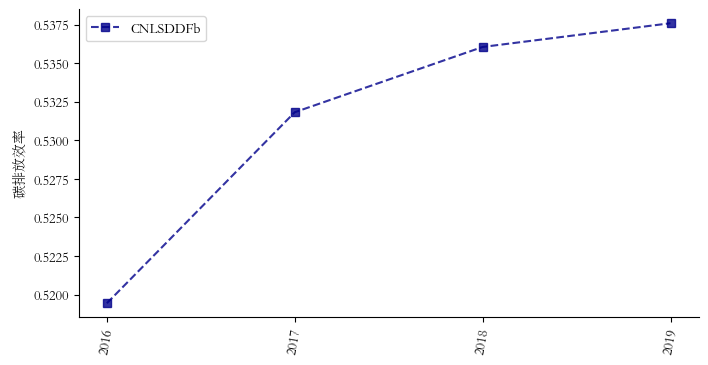

In [5]:
# 计算VRS不同方向模型下各年份的平均碳排放效率
CNLSDDFb_mean_year = CNLSDDFb_VRS_DIFF3['TE'].mean()
xtick2 = tuple(CNLSDDFb_mean_year.index)  # 获取年份标签

# 导入可视化库
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

# 设置中文字体与负号显示
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['STSong']  # 设置中文字体为华文宋体
rcParams['axes.unicode_minus'] = False

# 创建图形和坐标轴
import numpy as np
fig, ax = plt.subplots(figsize=(8, 4))

# 美化图形：隐藏顶部和右侧边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

############################ 绘图设置 #################################
n_groups = 4  # 分组数量（对应4个年份）
index = np.arange(n_groups)  # 生成x轴位置 [0,1,2,3]
# 注：bar_width 与 error_config 沿用 notebook 历史设置，本折线图未实际使用，保留以与配套代码一致
bar_width = 0.5
error_config = {'ecolor': 'black', 'capsize': 2}

# 绘制碳排放效率趋势线（深蓝色虚线，方形标记）
rects1 = ax.plot(index, CNLSDDFb_mean_year,
                color='darkblue', alpha=0.8, 
                linestyle="dashed", marker="s",
                label='CNLSDDFb'  # 图例标签
              )

########################### 图表美化 #################################
ax.set_ylabel(r'$\mathregular{碳排放效率}$')  # 设置y轴标签（数学字体）
ax.set_xticks(index)  # 设置x轴刻度位置
ax.set_xticklabels(xtick2)  # 设置x轴刻度标签（年份）
plt.legend()  # 显示图例
plt.xticks(rotation=80)  # x轴标签旋转80度防止重叠

# 根据分析类型保存图形
if kind == "province":
   plt.savefig("chap10分年份碳排放效率-省.png",  # 省份级结果
              dpi=900,  # 高分辨率
              bbox_inches='tight')  # 自动调整边界
else:
   plt.savefig("chap10分年份碳排放效率-国.png",  # 国家级结果
              dpi=900,
              bbox_inches='tight')

plt.show()  # 显示图形

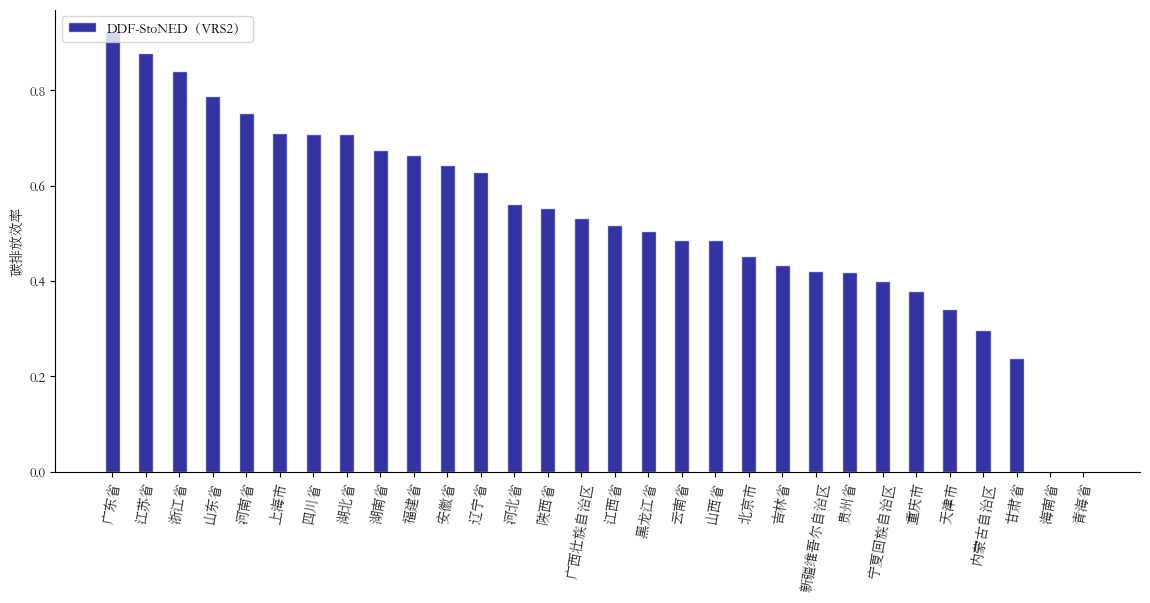

In [6]:
# 计算VRS2模型下各省份2016-2019年的平均碳排放效率，并降序排列
CNLSDDFb_mean_cou = CNLSDDFb_VRS_DIFF3['TE'].mean(axis=1)
CNLSDDFb_mean_cou = CNLSDDFb_mean_cou.sort_values(ascending=False)

# 绘制省份排序柱状图
xtick2 = tuple(CNLSDDFb_mean_cou.index)
fig, ax = plt.subplots(figsize=(14, 6))
ax.spines['top'].set_visible(False)      # 隐藏顶部边框
ax.spines['right'].set_visible(False)    # 隐藏右侧边框

x_values = np.arange(len(CNLSDDFb_mean_cou))
ax.bar(
    x_values, CNLSDDFb_mean_cou,
    width=0.45, color='darkblue', alpha=0.8, edgecolor='white',
    label='DDF-StoNED（VRS2）',
)
ax.set_ylabel('碳排放效率')
ax.set_xticks(x_values)
ax.set_xticklabels(CNLSDDFb_mean_cou.index, rotation=80)
ax.legend(loc='upper left')

# 根据分析类型保存图形
if kind == "province":
    fig.savefig("chap10分省份碳排放效率-省.png", dpi=900, bbox_inches='tight')
else:
    fig.savefig("chap10分省份碳排放效率-国.png", dpi=900, bbox_inches='tight')
plt.show()

## 10.6.2 CNLSDweak：含非期望产出的谢泼德距离函数


In [7]:
# 三种规模报酬设定下分别求解 CNLSSDweak，返回 Shephard 技术效率数组
def solve_sd(rts):
    model = CNLSSDFDDFweak.CNLSSDweak(
        data, sent="K L E=Y:CO2", gy=[0], gx=[0,0,0], gb=[1],
        cet=CET_MULT, rts=rts, fun=FUN_PROD
    )
    model.optimize(solver="knitro")
    rd = StoNED.StoNED(model)
    return rd.get_technical_efficiency(RED_QLE)

TE_crs  = solve_sd(RTS_CRS)    # CRS
TE_vrs1 = solve_sd(RTS_VRS1)   # VRS 相同减排因子
TE_vrs2 = solve_sd(RTS_VRS2)   # VRS 不同减排因子（标准 VRS）

Optimizing locally.
for solver asl. File with name=knitro either does not exist or it is not
executable. To skip this validation, call set_executable with validate=False.
Traceback (most recent call last):
  File "D:\ProgramData\anaconda3\envs\demo\Lib\site-packages\pyomo\opt\base\solvers.py", line 162, in __call__
    opt = self._cls[_implicit_solvers[mode]](**kwds)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\ProgramData\anaconda3\envs\demo\Lib\site-packages\pyomo\solvers\plugins\solvers\ASL.py", line 46, in __init__
    SystemCallSolver.__init__(self, **kwds)
  File "D:\ProgramData\anaconda3\envs\demo\Lib\site-packages\pyomo\opt\solver\shellcmd.py", line 66, in __init__
    self.set_executable(name=executable, validate=validate)
  File "D:\ProgramData\anaconda3\envs\demo\Lib\site-packages\pyomo\opt\solver\shellcmd.py", line 115, in set_executable
    raise ValueError(
ValueError: Failed to set executable for solver asl. File with name=knitro either does not exist 

Estimating the multiplicative model locally with knitro solver.


Estimating the multiplicative model locally with knitro solver.


Artelys Knitro 14.2.0: soltype=1

          Commercial License
         Artelys Knitro 14.2.0

Knitro using up to 16 threads.
No start point provided -- Knitro computing one.

Knitro presolve eliminated 120 variables and 120 constraints.

concurrent_evals         0
datacheck                0
findiff_numthreads       1
hessian_no_f             1
hessopt                  1
soltype                  1
Knitro fixing 120 variables eliminated from the presolve.

Problem Characteristics                                 (   Presolved)
-----------------------
Objective goal:  Minimize
Objective type:  quadratic
Number of variables:                                840 (         720)
    bounded below only:                             720 (         600)
    bounded above only:                               0 (           0)
    bounded below and above:                          0 (           0)
    fixed:                                            0 (           0)
    free:                            

      23    3.831684e+03   2.457e-04   2.307e-09   1.069e+00        0

EXIT: Locally optimal solution found.

NOTE: Knitro returning the best feasible iterate.

Final Statistics
----------------
Final objective value               =   3.83168361917538e+03
Final feasibility error (abs / rel) =   2.46e-04 / 6.90e-12
Final optimality error  (abs / rel) =   2.31e-09 / 1.69e-10
# of iterations                     =         23 
# of CG iterations                  =          0 
# of function evaluations           =         27
# of gradient evaluations           =         25
# of Hessian evaluations            =         23
Total program time (secs)           =       0.323 (     0.391 CPU time)
Time spent in evaluations (secs)    =       0.002




...

Optimizing locally.
Estimating the multiplicative model locally with knitro solver.


Artelys Knitro 14.2.0: 
          Commercial License
         Artelys Knitro 14.2.0

Knitro using up to 16 threads.
No start point provided -- Knitro computing one.

Knitro presolve eliminated 120 variables and 120 constraints.

concurrent_evals         0
datacheck                0
findiff_numthreads       1
hessian_no_f             1
hessopt                  1
Knitro fixing 120 variables eliminated from the presolve.

Problem Characteristics                                 (   Presolved)
-----------------------
Objective goal:  Minimize
Objective type:  quadratic
Number of variables:                                960 (         840)
    bounded below only:                             720 (         600)
    bounded above only:                               0 (           0)
    bounded below and above:                          0 (           0)
    fixed:                                            0 (           0)
    free:                                           240 (         240)
Num

      10    1.843480e+03   1.813e+07   8.713e+00   1.936e+06        0
      20    3.262858e+03   9.037e+06   1.175e+01   1.768e+06        0


      30    4.086813e+03   3.220e+06   1.352e+01   4.777e+06        0
      40    4.163620e+03   7.524e+05   1.396e+01   1.591e+07        0


      50    3.831684e+03   7.712e-05   2.036e-09   7.037e-06        1

EXIT: Locally optimal solution found.

Final Statistics
----------------
Final objective value               =   3.83168361897921e+03
Final feasibility error (abs / rel) =   7.71e-05 / 2.10e-12
Final optimality error  (abs / rel) =   2.04e-09 / 1.49e-10
# of iterations                     =         50 
# of CG iterations                  =          1 
# of function evaluations           =         60
# of gradient evaluations           =         52
# of Hessian evaluations            =         50
Total program time (secs)           =       2.374 (     6.422 CPU time)
Time spent in evaluations (secs)    =       0.002




## 10.6.3 weakCNQR：含非期望产出的凸非参数分位数回归


In [8]:
from deabook.CQERDFDDFweak import CQRweak
from deabook.constant import FUN_PROD, RTS_VRS, CET_ADDI

# CQRweak：含非期望产出 CO2 的凸非参数分位数回归，tau=0.5。
def solve_CQRweak_CO2(tau=0.5):
    model = CQRweak(
        data,
        sent="K L E=Y:CO2",
        tau=tau,
        cet=CET_ADDI,
        fun=FUN_PROD,
        rts=RTS_VRS,
    )
    model.optimize(solver="mosek")
    return model.get_technical_efficiency()

CQRweak_TE = solve_CQRweak_CO2(tau=0.5)
CQRweak_TE2 = pd.concat([data, pd.DataFrame(CQRweak_TE, columns=["TE"])], axis=1)
CQRweak_TE3 = CQRweak_TE2.pivot_table(
    values=["TE"], index=dmuname, columns="year", aggfunc="mean",
    fill_value=None, margins=False, dropna=True, observed=False,
)
CQRweak_TE3 = CQRweak_TE3.sort_values(by=("TE", 2017))
CQRweak_TE3.to_markdown("table10.9_CQRweak_TE.md")
CQRweak_TE3


Optimizing locally.
Estimating the additive model locally with mosek solver.


Problem


  Name                   :                 


  Objective sense        : minimize        


  Type                   : LO (linear optimization problem)


...

  Problem status  : PRIMAL_AND_DUAL_FEASIBLE


  Solution status : OPTIMAL


  Primal.  obj: 7.7092379150e+03    nrm: 2e+03    Viol.  con: 2e-05    var: 0e+00  


  Dual.    obj: 7.7092379149e+03    nrm: 6e+06    Viol.  con: 7e-15    var: 2e-07  


TE                              
year          2016      2017      2018      2019
省份                                              
内蒙古自治区    0.630904  0.656683  0.683464  0.711386
贵州省       0.720213  0.682258  0.698742  0.657158
甘肃省       0.766087  0.762109  0.720624  0.717612
河北省       0.847230  0.796372  0.764385  0.735762
新疆维吾尔自治区  0.838311  0.813136  0.813340  0.710344
云南省       0.971577  0.909278  0.852620  0.859700
黑龙江省      0.951560  0.918266  1.000000  1.000000
四川省       0.873709  0.925414  1.000000  0.958962
陕西省       0.904061  0.926758  0.959094  0.902636
河南省       0.894035  0.938568  0.972858  1.000000
广西壮族自治区   0.975159  0.940398  0.958094  0.923547
江西省       1.000000  0.941321  0.951371  0.912606
湖北省       0.970169  0.943757  1.000000  1.000000
辽宁省       0.912265  0.946350  1.000000  1.000000
重庆市       1.000000  0.959932  0.997146  1.000000
安徽省       0.957857  0.960010  1.000000  0.981677
湖南省       1.000000  0.976740  1.000000  1.000000
山东省       1.000000  1.000000  0.995552  1.000000
山西省       0.889221  1.000000  0.998337  1.000000
上海市       1.000000  1.000000  1.000000  1.000000
北京市       1.000000  1.000000  1.000000  1.000000
吉林省       1.000000  1.000000  1.000000  1.000000
天津市       1.000000  1.000000  1.000000  1.000000
宁夏回族自治区   1.000000  1.000000  1.000000  1.000000
江苏省       1.000000  1.000000  1.000000  1.000000
广东省       1.000000  1.000000  1.000000  1.000000
浙江省       1.000000  1.000000  1.000000  1.000000
海南省       1.000000  1.000000  1.000000  1.000000
福建省       1.000000  1.000000  1.000000  1.000000
青海省       1.000000  1.000000  1.000000  1.000000

## 10.6.4 weakCNQRDDF：含非期望产出的方向距离函数分位数回归


In [9]:
from deabook.CQERDFDDFweak import CQRDDFweak
from deabook.constant import FUN_PROD, RTS_VRS

# CQRDDFweak：含非期望产出 CO2 的 DDF 分位数回归，方向设为压缩非期望产出。
def solve_CQRDDFweak_CO2(tau=0.5):
    model = CQRDDFweak(
        data,
        sent="K L E=Y:CO2",
        tau=tau,
        gy=[0],
        gx=[0, 0, 0],
        gb=[1],
        fun=FUN_PROD,
        rts=RTS_VRS,
    )
    model.optimize(solver="mosek")
    return model.get_technical_efficiency()

CQRDDFweak_TE = solve_CQRDDFweak_CO2(tau=0.5)
CQRDDFweak_TE2 = pd.concat([data, pd.DataFrame(CQRDDFweak_TE, columns=["TE"])], axis=1)
CQRDDFweak_TE3 = CQRDDFweak_TE2.pivot_table(
    values=["TE"], index=dmuname, columns="year", aggfunc="mean",
    fill_value=None, margins=False, dropna=True, observed=False,
)
CQRDDFweak_TE3 = CQRDDFweak_TE3.sort_values(by=("TE", 2017))
CQRDDFweak_TE3.to_markdown("table10.10_CQRDDFweak_TE.md")
CQRDDFweak_TE3


D:\BaiduSyncdisk\software\deabook\deabook\CQERDFDDFweak.py:231: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return sum(model.beta[i, j] * self.gx[j] for j in model.J) + sum(model.gamma[i, k] * self.gy[k] for k in model.K) + sum(model.delta[i, l] * self.gb[l] for l in model.L) == 1


Optimizing locally.
Estimating the additive model locally with mosek solver.


Problem


  Name                   :                 


  Objective sense        : minimize        


...

  Problem status  : PRIMAL_AND_DUAL_FEASIBLE


  Solution status : OPTIMAL


  Primal.  obj: 7.8741089192e+03    nrm: 9e+04    Viol.  con: 2e-11    var: 2e-15  


  Dual.    obj: 7.8741089192e+03    nrm: 1e+07    Viol.  con: 4e-15    var: 2e-07  


TE                              
year          2016      2017      2018      2019
省份                                              
内蒙古自治区    0.192140  0.184144  0.167551  0.154724
新疆维吾尔自治区  0.299146  0.295634  0.306221  0.283393
山西省       0.386503  0.404158  0.376229  0.360471
贵州省       0.442379  0.451669  0.471536  0.460735
甘肃省       0.501357  0.520899  0.500745  0.502627
河北省       0.540364  0.562433  0.445686  0.448644
黑龙江省      0.612026  0.599185  0.647969  0.585646
辽宁省       0.633149  0.616096  0.581570  0.569768
吉林省       0.692920  0.679891  0.697427  0.679887
安徽省       0.724383  0.735796  0.725161  0.715860
陕西省       0.707620  0.749837  0.733582  0.694995
江西省       0.846868  0.814676  0.797430  0.783704
山东省       0.835321  0.862561  0.767151  0.741892
河南省       0.808459  0.866572  0.904017  0.969961
广西壮族自治区   0.894349  0.882318  0.867406  0.831987
天津市       0.812371  0.886465  0.841416  0.821184
云南省       0.993013  0.948058  0.901138  1.000000
重庆市       0.955570  0.948617  0.943818  0.999036
湖南省       1.000000  0.988286  0.996703  1.000000
青海省       1.000000  1.000000  1.000000  1.000000
北京市       1.000000  1.000000  1.000000  1.000000
上海市       1.000000  1.000000  1.000000  1.000000
四川省       1.000000  1.000000  1.000000  1.000000
宁夏回族自治区   0.755546  1.000000  0.981460  1.000000
江苏省       1.000000  1.000000  1.000000  1.000000
广东省       1.000000  1.000000  1.000000  1.000000
浙江省       1.000000  1.000000  1.000000  1.000000
海南省       1.000000  1.000000  1.000000  1.000000
福建省       1.000000  1.000000  1.000000  1.000000
湖北省       1.000000  1.000000  1.000000  1.000000